# Data Quality and Feature Engineering

## tl;dr

- The deterministic demonstration source contains 1,661 pitch rows across 16 eligible starts.
- Every retained pitch has a same-game, same-pitch-type early baseline in this controlled sample.
- The conservative fastball procedure establishes its first sustained threshold at pitches 91–100.
- These values validate the software path only; they are synthetic and are not an MLB finding.

## Context & Methods

This companion notebook audits the raw-to-feature path used by the Streamlit
application. It reconstructs cumulative game pitch count before filtering,
checks pitch-level grain, and calculates each early-game baseline separately by
`game_pk` and `pitch_type`.

### Key Assumptions

- A starter appearance begins in inning 1 and contains at least 40 observed pitches.
- The fresh baseline is the mean of at least two same-type pitches among the first 25 game pitches.
- Ten-pitch bucket estimates give every game equal weight.
- Confidence intervals resample games, not individual pitches.

## Data

### 1. Load the deterministic sample

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from pitcher_fatigue.config import AnalysisConfig
from pitcher_fatigue.pipeline import analyze_pitcher_frame

sample_path = ROOT / "data" / "sample" / "sample_pitcher.csv"
raw = pd.read_csv(sample_path, low_memory=False)
raw.shape

(1661, 18)

### 2. Validate source grain and physical ranges

In [2]:
config = AnalysisConfig()
bundle = analyze_pitcher_frame(
    raw,
    provenance={"source": "deterministic_synthetic_demo"},
    config=config,
    train_models=False,
)

quality_summary = pd.Series(bundle.quality_report.to_dict()).drop("issues")
quality_summary

status                                                         ready
rows_input                                                      1661
rows_clean                                                      1661
games                                                             16
eligible_starts                                                   16
source_as_of                                              2024-07-01
metrics            {'exact_duplicates_removed': 0, 'duplicate_pit...
dtype: object

In [3]:
bundle.quality_report.to_frame()

,check,severity,evidence,impact,remediation


## Results

### 3. Verify pitch-type-specific baselines

In [4]:
baseline_audit = (
    bundle.features[
        [
            "game_pk",
            "pitch_type",
            "baseline_speed",
            "baseline_pitch_count",
            "baseline_available",
        ]
    ]
    .drop_duplicates()
    .sort_values(["game_pk", "pitch_type"])
)
baseline_audit.head(12)

,game_pk,pitch_type,baseline_speed,baseline_pitch_count,baseline_available
3,900000,CH,87.313917,4,True
0,900000,FF,95.859494,9,True
2,900000,SI,93.713280,3,True
1,900000,SL,85.652261,9,True
102,900001,CH,88.101655,6,True
99,900001,FF,96.136969,9,True
101,900001,SI,94.249786,6,True
100,900001,SL,86.161444,4,True
200,900002,CH,87.632420,4,True
197,900002,FF,95.603260,12,True


In [5]:
assert not bundle.features.duplicated(
    ["game_pk", "at_bat_number", "pitch_number"]
).any()
assert bundle.features.groupby("game_pk")["game_pitch_count"].min().eq(1).all()
assert bundle.features.loc[
    bundle.features["baseline_available"], "baseline_speed"
].notna().all()
bundle.coverage

{'rows': 1661,
 'games': 16,
 'pitch_types': 4,
 'baseline_rows': 1661,
 'baseline_coverage': 1.0,
 'late_games_80_plus': 16,
 'velocity_coverage': 1.0,
 'spin_rate_coverage': 0.9957856712823601,
 'extension_coverage': 1.0,
 'horizontal_break_coverage': 1.0,
 'vertical_break_coverage': 1.0,
 'spin_rate_mnar_shift': -0.00625}

### 4. Plot the game-weighted fastball fatigue curve

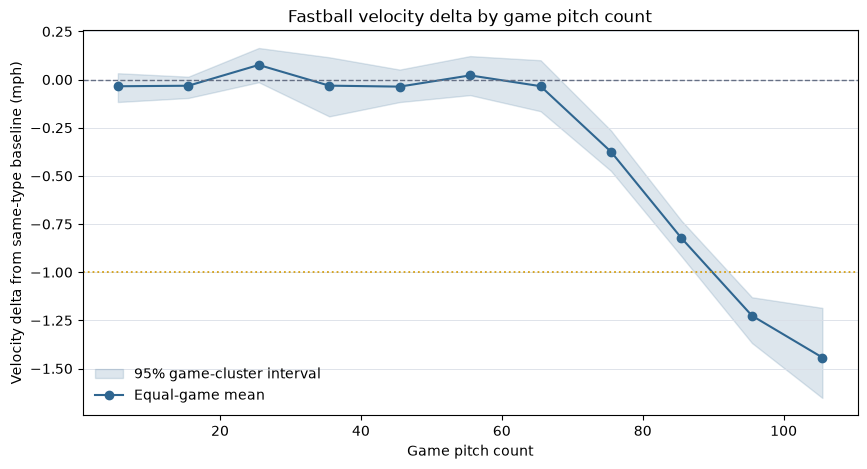

In [6]:
curve = bundle.velocity_curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(
    curve["pitch_count_bucket_mid"],
    curve["ci_lower"],
    curve["ci_upper"],
    color="#2F6690",
    alpha=0.16,
    label="95% game-cluster interval",
)
ax.plot(
    curve["pitch_count_bucket_mid"],
    curve["mean_delta"],
    color="#2F6690",
    marker="o",
    label="Equal-game mean",
)
ax.axhline(0, color="#667085", linestyle="--", linewidth=1)
ax.axhline(-1, color="#D4A017", linestyle=":", linewidth=1.3)
ax.set(
    title="Fastball velocity delta by game pitch count",
    xlabel="Game pitch count",
    ylabel="Velocity delta from same-type baseline (mph)",
)
ax.legend(frameon=False)
ax.grid(axis="y", color="#D9DEE7", linewidth=0.6)
plt.show()

In [7]:
pd.DataFrame(
    {
        "status": [bundle.threshold.status],
        "threshold_range": [bundle.threshold.threshold_range],
        "reason": [bundle.threshold.reason],
    }
)

,status,threshold_range,reason
0,established,91–100,First sustained bucket meeting the velocity-dr...


## Takeaways

The deterministic sample passes the intended feature-engineering checks. Pitch
count is reconstructed before tracking filters, baselines do not mix pitch
types, and threshold uncertainty respects game-level dependence. A real
pitcher-season must pass the same coverage and data-quality gates before its
results can be shared.